In [2]:
import pandas as pd
import numpy as np
# import seaborn as 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/shared/hbcd-1-0-release-tabulated-prod/img_bibsnet_space-T1w_desc-aseg_volumes.tsv', sep='\t')
df.head

<bound method NDFrame.head of      participant_id session_id  \
0    sub-6828199012    ses-V02   
1    sub-5389374171    ses-V02   
2    sub-4928693897    ses-V02   
3    sub-2686683014    ses-V02   
4    sub-5294765818    ses-V02   
..              ...        ...   
143  sub-4336352944    ses-V03   
144  sub-4550084339    ses-V03   
145  sub-3357439820    ses-V03   
146  sub-9280132120    ses-V03   
147  sub-8605034607    ses-V03   

     img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age  \
0                                                0.049       
1                                                0.066       
2                                                0.107       
3                                                0.118       
4                                                0.194       
..                                                 ...       
143                                              0.611       
144                                              0.416       
145

# Add UMA Data

## Remember the LCortex plot

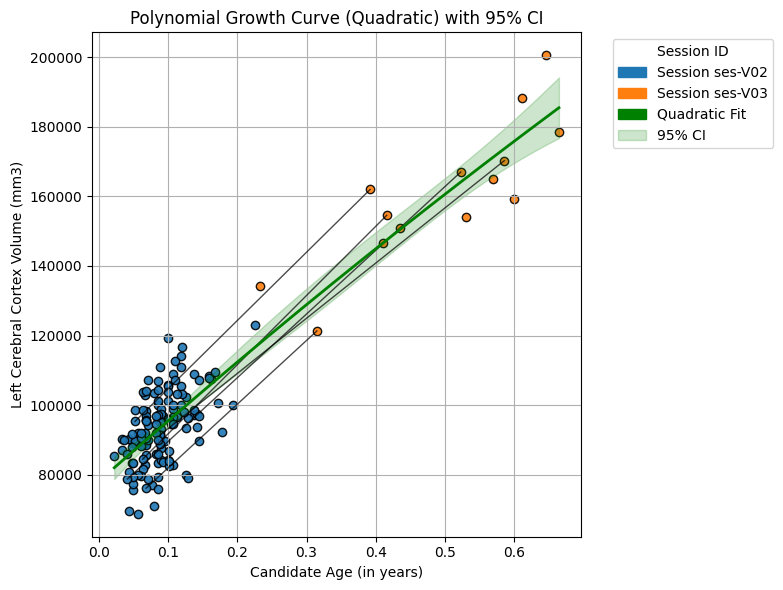

In [19]:
# Color mapping for sessions
color_palette = plt.cm.tab10.colors
session_ids = sorted(df['session_id'].unique())
session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

plt.figure(figsize=(8,6))

# Plot points by session color and connect lines by subject
for pid, group in df.groupby('participant_id'):
    group_sorted = group.sort_values('img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age')
    for sid in session_ids:
        session_group = group_sorted[group_sorted['session_id'] == sid]
        if not session_group.empty:
            plt.scatter(session_group['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                        session_group['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                        color=session_colors[sid], alpha=0.9, edgecolor='black', label=None)
    if len(group_sorted) > 1:
        plt.plot(group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                 group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                 color='black', alpha=0.7, linewidth=1)

# Plot polynomial fit with CI
plt.plot(x_curve, y_poly, color='green', linewidth=2, label='Quadratic Fit')
plt.fill_between(x_curve, ci_lower, ci_upper, color='green', alpha=0.2, label='95% CI')

# Custom legend
handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
handles += [
    mpatches.Patch(color='green', label='Quadratic Fit'),
    mpatches.Patch(color='green', alpha=0.2, label='95% CI')
]
plt.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume (mm3)')
plt.title('Polynomial Growth Curve (Quadratic) with 95% CI')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Load UMA data
df_uma = pd.read_csv('df_merged.csv')

df_uma.head

<bound method NDFrame.head of    subject_id  Left-Cerebral-White-Matter  Left-Cerebral-Cortex  \
0    BB005_01                 119205.0000           133461.0000   
1    BB007_01                 151230.8776           204543.9839   
2    BB013_01                 125802.0000           159648.0000   
3    BB015_01                 129846.0000           163035.0000   
4    BB016_01                 141650.0000           181617.0000   
..        ...                         ...                   ...   
57   BB123_01                 144308.0000           201569.0000   
58   BB124_01                 142436.0000           197058.0000   
59   BB125_01                 119723.0000           165206.0000   
60   BB127_01                 144078.0000           201649.0000   
61   BB129_02                 143980.0000           198044.0000   

    Left-Lateral-Ventricle  Left-Cerebellum-Cortex  Left-Thalamus-Proper  \
0              2638.000000             25567.00000           5625.000000   
1            

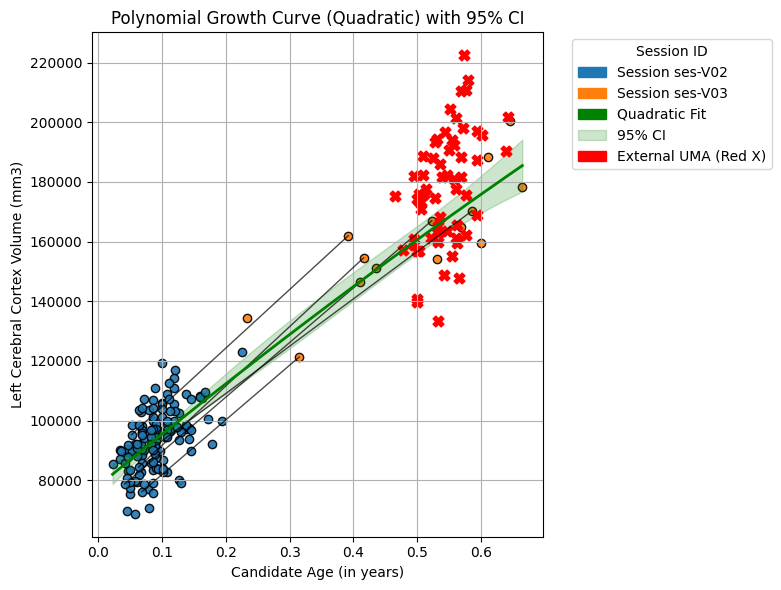

In [21]:
# ammend the plot
# Color mapping for sessions
color_palette = plt.cm.tab10.colors
session_ids = sorted(df['session_id'].unique())
session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

external_color = 'red'
external_marker = 'X'

plt.figure(figsize=(8,6))

# Plot points by session color and connect lines by subject
for pid, group in df.groupby('participant_id'):
    group_sorted = group.sort_values('img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age')
    for sid in session_ids:
        session_group = group_sorted[group_sorted['session_id'] == sid]
        if not session_group.empty:
            plt.scatter(session_group['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                        session_group['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                        color=session_colors[sid], alpha=0.9, edgecolor='black', label=None)
    if len(group_sorted) > 1:
        plt.plot(group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age'],
                 group_sorted['img_bibsnet_space-T1w_desc-aseg_volumes_Left-Cerebral-Cortex'],
                 color='black', alpha=0.7, linewidth=1)

# Plot polynomial fit with CI
plt.plot(x_curve, y_poly, color='green', linewidth=2, label='Quadratic Fit')
plt.fill_between(x_curve, ci_lower, ci_upper, color='green', alpha=0.2, label='95% CI')

# Custom legend
handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
handles += [
    mpatches.Patch(color='green', label='Quadratic Fit'),
    mpatches.Patch(color='green', alpha=0.2, label='95% CI')
]
external_patch = mpatches.Patch(color=external_color, label='External UMA (Red X)')
handles += [external_patch]

plt.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Candidate Age (in years)')
plt.ylabel('Left Cerebral Cortex Volume (mm3)')
plt.title('Polynomial Growth Curve (Quadratic) with 95% CI')
plt.grid(True)
plt.tight_layout()

# Plot df_uma data as red X's
plt.scatter(
    df_uma['Baby Age at Scan (Years)'],
    df_uma['Left-Cerebral-Cortex'],
    color=external_color,
    marker=external_marker,
    s=60,   # size of marker
    label='External UMA'
)
plt.show()

# Paired and unis, UMA and HBCD, to PDF

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

def plot_and_export_regions(
    df,
    df_uma,
    age_col,
    participant_col,
    session_col,
    pdf_filename="all_growth_curves_plusUMA.pdf",
    prefix="img_bibsnet_space-T1w_desc-aseg_volumes_"
):
    # ---- Parameters for UMA overlay ----
    external_color = 'red'
    external_marker = 'X'
    uma_age_col = 'Baby Age at Scan (Years)'  # Age column in the UMA dataframe

    # Identify region columns and structure base names
    region_cols = [col for col in df.columns if col.startswith(prefix)]
    structure_names = [col.replace(prefix, '') for col in region_cols]
    pairs = {}
    singletons = []

    # Find pairs and unpaired
    for name, col in zip(structure_names, region_cols):
        if name.startswith('Left-'):
            base = name.replace('Left-', '')
            pairs.setdefault(base, {})['Left'] = col
        elif name.startswith('Right-'):
            base = name.replace('Right-', '')
            pairs.setdefault(base, {})['Right'] = col
        else:
            singletons.append((name, col))

    # Split pairs into true pairs and leftover singles
    paired_structures = {k: v for k, v in pairs.items() if len(v) == 2}
    leftover = [(f"Left-{k}", v['Left']) for k, v in pairs.items() if 'Left' in v and 'Right' not in v]
    leftover += [(f"Right-{k}", v['Right']) for k, v in pairs.items() if 'Right' in v and 'Left' not in v]
    all_singletons = singletons + leftover

    # Session colors
    color_palette = plt.cm.tab20.colors
    session_ids = sorted(df[session_col].unique())
    session_colors = dict(zip(session_ids, color_palette[:len(session_ids)]))

    with PdfPages(pdf_filename) as pdf:
        # -- Plot left-right pairs --
        for base_name, pair in paired_structures.items():
            fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
            sides = ['Left', 'Right']
            for i, side in enumerate(sides):
                region_col = pair[side]
                region_name = f"{side}-{base_name}"
                x = df[age_col].values
                y = df[region_col].values
                # Polynomial fit and CI
                coefs = np.polyfit(x, y, 2)
                x_curve = np.linspace(x.min(), x.max(), 200)
                y_poly = np.polyval(coefs, x_curve)
                X = np.vstack([x**2, x, np.ones_like(x)]).T
                X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T
                y_fit = np.polyval(coefs, x)
                residuals = y - y_fit
                dof = len(x) - 3
                residual_var = (residuals**2).sum() / dof
                XtX_inv = np.linalg.inv(X.T @ X)
                y_var_pred = np.array([residual_var * (np.dot(X_pred[j], XtX_inv @ X_pred[j])) for j in range(len(x_curve))])
                y_std_pred = np.sqrt(y_var_pred)
                ci_upper = y_poly + 1.96 * y_std_pred
                ci_lower = y_poly - 1.96 * y_std_pred
                ax = axes[i]
                # Plot session colored points and lines
                for pid, group in df.groupby(participant_col):
                    group_sorted = group.sort_values(age_col)
                    for sid in session_ids:
                        session_group = group_sorted[group_sorted[session_col] == sid]
                        if not session_group.empty:
                            ax.scatter(
                                session_group[age_col], session_group[region_col],
                                color=session_colors[sid], alpha=0.9, edgecolor='black', label=None
                            )
                    if len(group_sorted) > 1:
                        ax.plot(
                            group_sorted[age_col], group_sorted[region_col],
                            color='black', alpha=0.7, linewidth=1
                        )
                # Poly fit curve and CI
                ax.plot(x_curve, y_poly, color='green', linewidth=2, label='Quadratic Fit')
                ax.fill_between(x_curve, ci_lower, ci_upper, color='green', alpha=0.2, label='95% CI')
                # --- Overlay UMA data, if available for this region ---
                uma_structure_col = region_name
                if uma_structure_col in df_uma.columns:
                    ax.scatter(
                        df_uma[uma_age_col],
                        df_uma[uma_structure_col],
                        color=external_color, marker=external_marker, s=80,
                        label='UMA Data'
                    )
                ax.set_xlabel('Age (years)')
                ax.set_title(region_name)
            
            # Legend (custom handles, add UMA marker)
            handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
            handles += [
                mpatches.Patch(color='green', label='Quadratic Fit'),
                mpatches.Patch(color='green', alpha=0.2, label='95% CI'),
                plt.Line2D([0], [0], color=external_color, marker=external_marker, linestyle='', markersize=10, label='UMA Data (Red X)')
            ]
            axes[0].legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')
            axes[0].set_ylabel('Volume (mm³)')
            for ax in axes:
                ax.grid(True)
            plt.suptitle(f'Polynomial Growth Curve: {base_name} (Left/Right)', fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            pdf.savefig(fig)
            plt.close(fig)

        # -- Plot unpaired structures --
        for region_name, region_col in all_singletons:
            fig, ax = plt.subplots(figsize=(12, 7))
            x = df[age_col].values
            y = df[region_col].values
            # Polynomial fit and CI
            coefs = np.polyfit(x, y, 2)
            x_curve = np.linspace(x.min(), x.max(), 200)
            y_poly = np.polyval(coefs, x_curve)
            X = np.vstack([x**2, x, np.ones_like(x)]).T
            X_pred = np.vstack([x_curve**2, x_curve, np.ones_like(x_curve)]).T
            y_fit = np.polyval(coefs, x)
            residuals = y - y_fit
            dof = len(x) - 3
            residual_var = (residuals**2).sum() / dof
            XtX_inv = np.linalg.inv(X.T @ X)
            y_var_pred = np.array([residual_var * (np.dot(X_pred[j], XtX_inv @ X_pred[j])) for j in range(len(x_curve))])
            y_std_pred = np.sqrt(y_var_pred)
            ci_upper = y_poly + 1.96 * y_std_pred
            ci_lower = y_poly - 1.96 * y_std_pred
            # Plot session colored points and lines
            for pid, group in df.groupby(participant_col):
                group_sorted = group.sort_values(age_col)
                for sid in session_ids:
                    session_group = group_sorted[group_sorted[session_col] == sid]
                    if not session_group.empty:
                        ax.scatter(
                            session_group[age_col], session_group[region_col],
                            color=session_colors[sid], alpha=0.9, edgecolor='black', label=None
                        )
                if len(group_sorted) > 1:
                    ax.plot(
                        group_sorted[age_col], group_sorted[region_col],
                        color='black', alpha=0.7, linewidth=1
                    )
            # Poly fit curve and CI
            ax.plot(x_curve, y_poly, color='green', linewidth=2, label='Quadratic Fit')
            ax.fill_between(x_curve, ci_lower, ci_upper, color='green', alpha=0.2, label='95% CI')

            # --- Overlay UMA data, if available for this region ---
            uma_structure_col = region_name
            if uma_structure_col in df_uma.columns:
                ax.scatter(
                    df_uma[uma_age_col],
                    df_uma[uma_structure_col],
                    color=external_color, marker=external_marker, s=80,
                    label='UMA Data'
                )

            # Legend (custom handles, add UMA marker)
            handles = [mpatches.Patch(color=session_colors[sid], label=f'Session {sid}') for sid in session_ids]
            handles += [
                mpatches.Patch(color='green', label='Quadratic Fit'),
                mpatches.Patch(color='green', alpha=0.2, label='95% CI'),
                plt.Line2D([0], [0], color=external_color, marker=external_marker, linestyle='', markersize=10, label='UMA Data (Red X)')
            ]
            ax.legend(handles=handles, title='Session ID', bbox_to_anchor=(1.05, 1), loc='upper left')

            ax.set_xlabel('Age (years)')
            ax.set_ylabel('Volume (mm³)')
            ax.set_title(region_name)
            ax.grid(True)
            plt.suptitle(f'Polynomial Growth Curve: {region_name}', fontsize=16)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            pdf.savefig(fig)
            plt.close(fig)

# Usage example:
plot_and_export_regions(
    df,
    df_uma,
    age_col='img_bibsnet_space-T1w_desc-aseg_volumes_candidate_age',
    participant_col='participant_id',
    session_col='session_id',
    prefix='img_bibsnet_space-T1w_desc-aseg_volumes_',
    pdf_filename='all_growth_curves_plusUMA.pdf'
)

In [23]:
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [24]:
import seaborn as sns
print(sns.__version__)

0.13.2


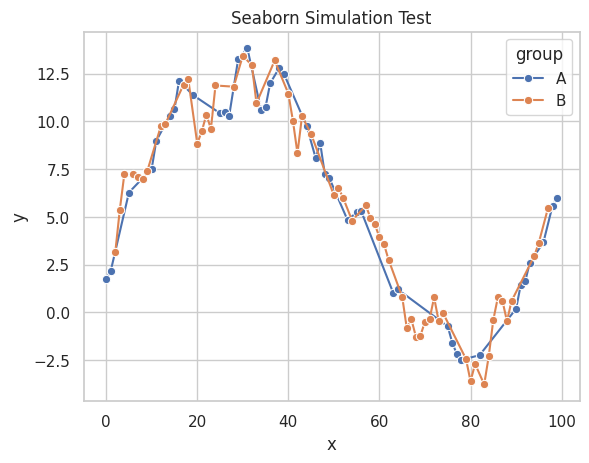

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Simulate data
np.random.seed(0)
df = pd.DataFrame({
    "x": np.arange(100),
    "y": np.random.normal(loc=0, scale=1, size=100).cumsum(),
    "group": np.random.choice(['A', 'B'], size=100)
})

# Simple seaborn lineplot
sns.set(style="whitegrid")
sns.lineplot(data=df, x="x", y="y", hue="group", marker="o")
plt.title("Seaborn Simulation Test")
plt.show()

In [26]:
mean_age = df_uma['Baby Age at Scan (Years)'].mean()
print(f"Average age of External UMA subjects: {mean_age:.2f} years")

Average age of External UMA subjects: 0.54 years


In [27]:
mean_age_months = mean_age * 12
print(f"Average age of External UMA subjects: {mean_age_months:.2f} months")


Average age of External UMA subjects: 6.50 months


In [29]:
num_subjects = len(df_uma)
print(f"Number of External UMA subjects: {num_subjects}")

Number of External UMA subjects: 62


In [30]:
mean_left_cortex = df_uma['Left-Cerebral-Cortex'].mean()
print(f"Mean Left-Cerebral-Cortex volume: {mean_left_cortex:.2f} mm³")

Mean Left-Cerebral-Cortex volume: 177101.24 mm³


In [31]:
std_left_cortex = df_uma['Left-Cerebral-Cortex'].std()
print(f"Standard deviation of Left-Cerebral-Cortex volume: {std_left_cortex:.2f} mm³")

Standard deviation of Left-Cerebral-Cortex volume: 19148.65 mm³


In [33]:
import numpy as np

# Assuming you already have these arrays:
# x_curve: array of ages (e.g., np.linspace, or similar)
# y_poly: array of fitted volumes
# ci_lower: lower bound of confidence interval
# ci_upper: upper bound of confidence interval

age_query = 0.54

# Interpolate to obtain the estimates at the specified age
fitted_volume = np.interp(age_query, x_curve, y_poly)
ci_lower_at_age = np.interp(age_query, x_curve, ci_lower)
ci_upper_at_age = np.interp(age_query, x_curve, ci_upper)

print(f"Estimated Left-Cerebral-Cortex volume at age {age_query:.2f} years: {fitted_volume:.2f} mm³")
print(f"95% CI: [{ci_lower_at_age:.2f}, {ci_upper_at_age:.2f}] mm³")

Estimated Left-Cerebral-Cortex volume at age 0.54 years: 166717.67 mm³
95% CI: [161755.63, 171679.71] mm³


In [34]:
target_age = 0.54
tolerance = 0.05  # Adjust as needed for your sample size

near_uma = df_uma[np.abs(df_uma['Baby Age at Scan (Years)'] - target_age) < tolerance]

In [35]:
uma_mean = near_uma['Left-Cerebral-Cortex'].mean()
uma_std = near_uma['Left-Cerebral-Cortex'].std()
print(f"UMA mean volume near age {target_age} years: {uma_mean:.2f} mm³ (SD={uma_std:.2f})")

UMA mean volume near age 0.54 years: 176054.50 mm³ (SD=19529.46)


In [36]:
print(f"HBCD estimated volume at age {target_age} years: {fitted_volume:.2f} mm³")
print(f"UMA observed mean volume at similar age: {uma_mean:.2f} mm³")
print(f"Difference (UMA - HBCD): {uma_mean - fitted_volume:.2f} mm³")

HBCD estimated volume at age 0.54 years: 166717.67 mm³
UMA observed mean volume at similar age: 176054.50 mm³
Difference (UMA - HBCD): 9336.83 mm³


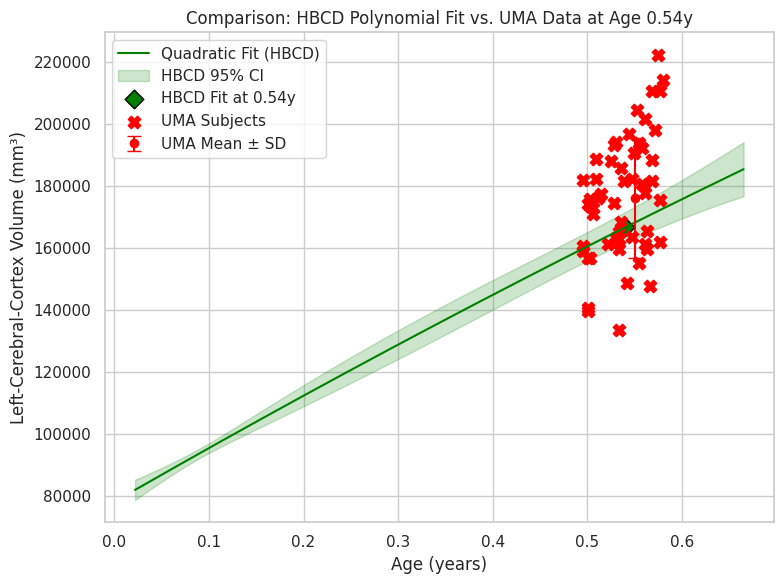

In [37]:
import matplotlib.pyplot as plt
import numpy as np

target_age = 0.54
tolerance = 0.05  # adjust as needed

# Interpolate the HBCD fit and CI at the target age
fit_volume = np.interp(target_age, x_curve, y_poly)
ci_lower_at_age = np.interp(target_age, x_curve, ci_lower)
ci_upper_at_age = np.interp(target_age, x_curve, ci_upper)

# Get UMA data near target age
near_uma = df_uma[np.abs(df_uma['Baby Age at Scan (Years)'] - target_age) < tolerance]
uma_volumes = near_uma['Left-Cerebral-Cortex'].values
uma_mean = np.mean(uma_volumes)
uma_std = np.std(uma_volumes)

plt.figure(figsize=(8,6))

# Plot HBCD fit and CI
plt.plot(x_curve, y_poly, color='green', label='Quadratic Fit (HBCD)')
plt.fill_between(x_curve, ci_lower, ci_upper, color='green', alpha=0.2, label='HBCD 95% CI')

# Mark the predicted HBCD value for target age
plt.scatter([target_age], [fit_volume], color='green', marker='D', s=90, edgecolor='black', label=f'HBCD Fit at {target_age:.2f}y')

# Plot UMA individual points
plt.scatter(near_uma['Baby Age at Scan (Years)'], uma_volumes, color='red', marker='X', s=80, label='UMA Subjects')

# Plot UMA mean with error bar (std)
plt.errorbar([target_age+0.01], [uma_mean], yerr=[uma_std], fmt='o', color='red', capsize=5, label='UMA Mean ± SD')

plt.xlabel('Age (years)')
plt.ylabel('Left-Cerebral-Cortex Volume (mm³)')
plt.title('Comparison: HBCD Polynomial Fit vs. UMA Data at Age 0.54y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
from scipy import stats

# Assume HBCD_predicted_mean = fit_volume
# Assume HBCD_predicted_std = (ci_upper_at_age - ci_lower_at_age) / 3.92  # Approximate SD from 95% CI (for normal)

# UMA data near age 0.54 years:
uma_volumes = near_uma['Left-Cerebral-Cortex'].values

# One-sample t-test: test if UMA mean equals HBCD predicted value
t_stat, p_value = stats.ttest_1samp(uma_volumes, fit_volume)
print(f"One-sample t-test p-value: {p_value:.3g}")

One-sample t-test p-value: 0.000914
